# Neural Network Regression

Neural network regression is a machine learning approach used to predict continuous numerical values by learning complex, non-linear relationships between input features and an output variable. It consists of interconnected layers of neurons that transform inputs through weighted connections and activation functions, allowing the model to capture patterns that traditional linear regression cannot. Neural network regression is widely used in applications such as house price prediction, sales and demand forecasting, energy consumption estimation, medical measurements prediction, and financial modeling, where accuracy depends on modeling intricate interactions among many variables.

---

# Anatomy and Architecture

| Hyperparameter               | Typical value                                                                                                   |
| ---------------------------- |-----------------------------------------------------------------------------------------------------------------|
| **Input layer shape**        | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| **Hidden layer(s)**          | Problem specific, minimum = 1, maximum = unlimited                                                              |
| **Neurons per hidden layer** | Problem specific, generally 10 to 100                                                                           |
| **Output layer shape**       | Same shape as desired prediction shape (e.g. 1 for house price)                                                 |
| **Hidden activation**        | Usually **ReLU** (rectified linear unit)                                                                        |
| **Output activation**        | None, ReLU, logistic/tanh                                                                                       |
| **Loss function**            | **MSE** (mean square error) or **MAE** (mean absolute error) / **Huber** (combination of MAE/MSE) if outliers   |
| **Optimizer**                | **SGD** (stochastic gradient descent), **Adam**                                                                 |
| **Epochs**                   | Problem specific, generally 100 to 1000                                                                         |
| **Batch size**               | Problem specific, generally 32 to 128                                                                           |
| **Learning rate**            | Problem specific, generally 0.001 to 0.0001                                                                     |
| **Metrics**                  | how well the model is doing                                                                                     |


## Regression Loss Functions


### `mean_squared_error` (MSE)
**Definition:**
Computes the **average squared difference** between predicted and true values.

**Formula:**
$L = \frac{1}{n} \sum (y - \hat{y})^2$

**When to use:**
- Continuous output (regression)
- Sensitive to outliers (large errors have big penalties)
**Examples:** Predicting house prices, temperature forecasting


### `mean_absolute_error` (MAE)
**Definition:**
Computes the **average absolute difference** between predicted and true values.

**Formula:**
$L = \frac{1}{n} \sum |y - \hat{y}|$

**When to use:**
- Continuous regression
- When you want equal penalty for all errors
**Examples:** Predicting age, demand forecasting


### `mean_absolute_percentage_error` (MAPE)
**Definition:**
Measures the average **percentage difference** between predicted and true values.

**Formula:**
$L = \frac{100}{n} \sum \left|\frac{y - \hat{y}}{y}\right|$

**When to use:**
- When scale of target values varies widely
- Output cannot contain zeros
**Examples:** Sales forecasting, economic data analysis


### `huber_loss`
**Definition:**
Combines the best of MAE and MSE — behaves like MSE for small errors and like MAE for large errors.

**Formula:**
\[
L =
\begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| < \delta \\
\delta \cdot (|y - \hat{y}| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}
\]

**When to use:**
- Regression with **outliers**
- More robust and stable than MSE or MAE
**Examples:** Noisy sensor data, real-world numeric predictions


### Workflow:
```
Build a model -> fit it -> evaluate it -> improve it -> fit it -> evaluate it -> improve it...
```

## Creating data

2026-01-19 04:01:52.565324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768788112.606724  180737 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768788112.621384  180737 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768788112.654856  180737 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768788112.654899  180737 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768788112.654903  180737 computation_placer.cc:177] computation placer alr

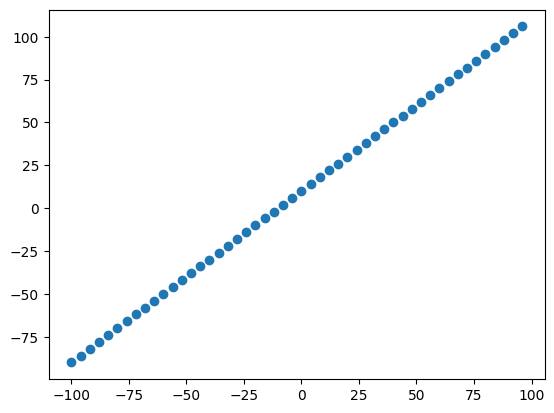

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Features
x = tf.range(-100, 100, 4)

# Labels
y = x+10

# Visualize data
plt.scatter(x, y)

## Splitting dataset

- **Training set** -> the model learns from this data - `{70-80%}` of the dataset
- **Validation set** -> the model gets tuned on this data - `{10-15%}` of the dataset
- **Test set** -> the model gets evaluated on this data - `{10-15%}` of the dataset

In [2]:
# Train
x_train = x[:40]
y_train = y[:40]

# Test
x_test = x[40:]
y_test = y[40:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

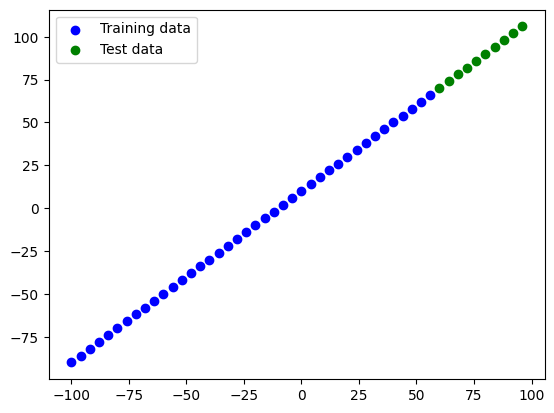

In [3]:
plt.scatter(x_train, y_train, c="blue", label="Training data")
plt.scatter(x_test, y_test, c="green", label="Test data")
plt.legend()

## Creating a model

In [4]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)), # Input layer
    tf.keras.layers.Dense(100, activation="relu"), # Hidden layer--|
    tf.keras.layers.Dense(100, activation="relu"), #               |
    tf.keras.layers.Dense(100, activation="relu"), #---------------|
    tf.keras.layers.Dense(1) # Output layer
])

## Compiling a model

In [5]:
model.compile(
    loss=tf.keras.losses.MAE,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

## Fitting a model

In [6]:
model.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100)

Epoch 1/100


I0000 00:00:1768788124.239690  180825 service.cc:152] XLA service 0x755c30003bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768788124.239760  180825 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-01-19 04:02:04.279922: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768788124.497078  180825 cuda_dnn.cc:529] Loaded cuDNN version 91400
2026-01-19 04:02:08.225030: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 8 bytes spill stores, 8 bytes spill loads

2026-01-19 04:02:08.951522: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_do

1/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 38.2939 - mae: 38.2939

I0000 00:00:1768788130.732574  180825 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - loss: 37.0058 - mae: 37.0058
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 13.0461 - mae: 13.0461
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 28.0131 - mae: 28.0131
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 25.1050 - mae: 25.1050
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 14.9457 - mae: 14.9457
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 13.3797 - mae: 13.3797
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 19.1885 - mae: 19.1885
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 18.8279 - mae: 18.8279
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 29.1791 - mae: 29.1791
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 14.5291 - mae: 14.5291
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 13.6996 - mae: 13.6996
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 25.9992 - mae: 25.9992
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 

## Model summary

Calling `summary()` on our model shows us the layers it contains, the output shape and the number of parameters.

- **Total params** - total number of parameters in the model.
- **Trainable parameters** - these are the parameters (patterns) the model can update as it trains.
- **Non-trainable parameters** - these parameters aren't updated during training (this is typical when you bring in the already learned patterns from other models during transfer learning).

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,503 (80.09 KB)

 Trainable params: 20,501 (80.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [8]:
from tensorflow.keras.utils import plot_model
plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## Making predictions

In [9]:
pred = model.predict(x_test)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[ 91.7618 ]
 [ 97.81682]
 [103.87389]
 [109.9105 ]
 [115.97002]
 [122.00317]
 [128.07262]
 [134.1304 ]
 [140.1778 ]
 [146.22531]]


In [10]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

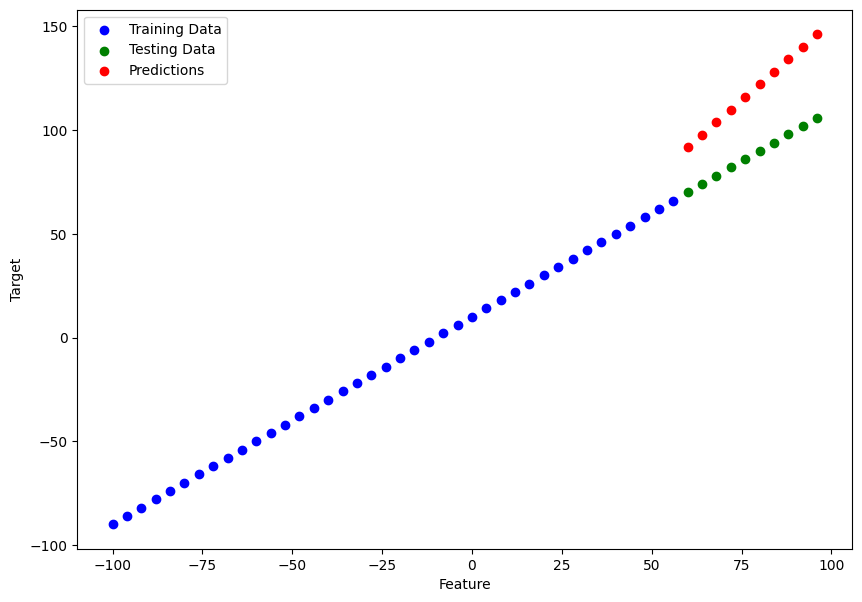

In [11]:
# visualizing predictions
def plot_predictions(train_data=x_train,
                     test_data=x_test,
                     train_labels=y_train,
                     test_labels=y_test,
                     predictions=pred):
    """
    Plots training data, test data, and model predictions.
    Converts inputs to 1-D numpy arrays and displays the plot.
    """
    td = np.asarray(train_data).ravel()
    tl = np.asarray(train_labels).ravel()
    vd = np.asarray(test_data).ravel()
    vl = np.asarray(test_labels).ravel()
    p = np.asarray(predictions).ravel()

    plt.figure(figsize=(10, 7))
    plt.scatter(td, tl, c="blue", label="Training Data")
    plt.scatter(vd, vl, c="green", label="Testing Data")
    plt.scatter(vd, p, c="red", label="Predictions")
    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.legend()
    plt.show()

plot_predictions()

## Improving a model [Hyperparameter tuning]

- Adding more layers
- Increasing the number of hidden units
- Changing the activation function
- Changing the optimizer
- Changing the learning rate
- Fitting on more data
- Fitting for longer

## Evaluating a model

- In evaluating a regression problem we use two metrics:
    * MAE` -> how wrong is each of my model's predictions.
    * MSE -> the average of the squared differences between predicted and actual values

In [12]:
model.evaluate(x_test, y_test) # it will be the same as the chosen loss func. when compiling the model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step - loss: 30.9942 - mae: 30.9942


[30.99423599243164, 30.99423599243164]

In [13]:
# MAE
def mae(yTest=y_test, prediction=pred):
    return tf.metrics.mae(yTest, tf.squeeze(prediction))
mae(y_test, pred)

<tf.Tensor: shape=(), dtype=float32, numpy=30.994232177734375>

In [14]:
# MSE
def mse(yTest=y_test, prediction=pred):
    return tf.metrics.mse(yTest, tf.squeeze(prediction))
mse(y_test, pred)

<tf.Tensor: shape=(), dtype=float32, numpy=995.3644409179688>

## Experimenting Models

**Model_1:**

In [15]:
# Set random seed
tf.random.set_seed(42)

# creating model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - loss: 97.2869 - mae: 97.2869  
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 62.5114 - mae: 62.5114
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 28.2167 - mae: 28.2167
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 9.6722 - mae: 9.6722
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.9602 - mae: 10.9602
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.9355 - mae: 7.9355
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.4004 - mae: 11.4004
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8.9222 - mae: 8.9222
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 10.0316 - mae: 10.0316
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.5300 - mae: 11.5300
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8.9981 - mae: 8.9981
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.1075 - mae: 10.1075
Epoch 13/100
2/2 ━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step


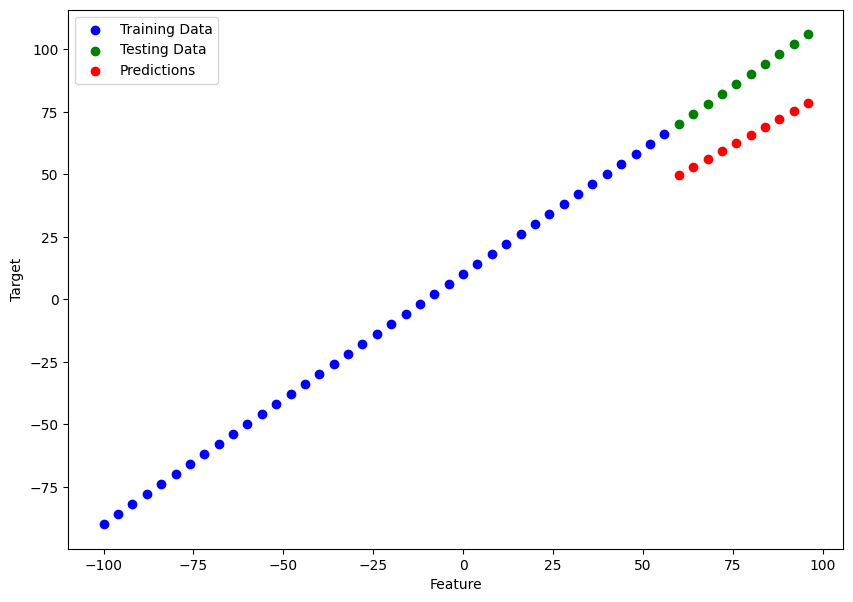

In [16]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(x_test)
plot_predictions(predictions=y_preds_1)

In [17]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(23.93546), np.float32(577.9925))

**Model_2:**

In [18]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_1 and add an extra layer
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(10), # add a second layer
  tf.keras.layers.Dense(1)
])

# Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_2.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 583ms/step - loss: 63.1019 - mae: 63.1019
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 27.7644 - mae: 27.7644
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.0165 - mae: 11.0165
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 13.5106 - mae: 13.5106
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 17.2565 - mae: 17.2565
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 10.2531 - mae: 10.2531
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11.1496 - mae: 11.1496
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.0638 - mae: 12.0638
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 13.0093 - mae: 13.0093
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.7405 - mae: 15.7405
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 9.7425 - mae: 9.7425
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.5232 - mae: 10.5232
Epoch 13/100
2/2 ━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


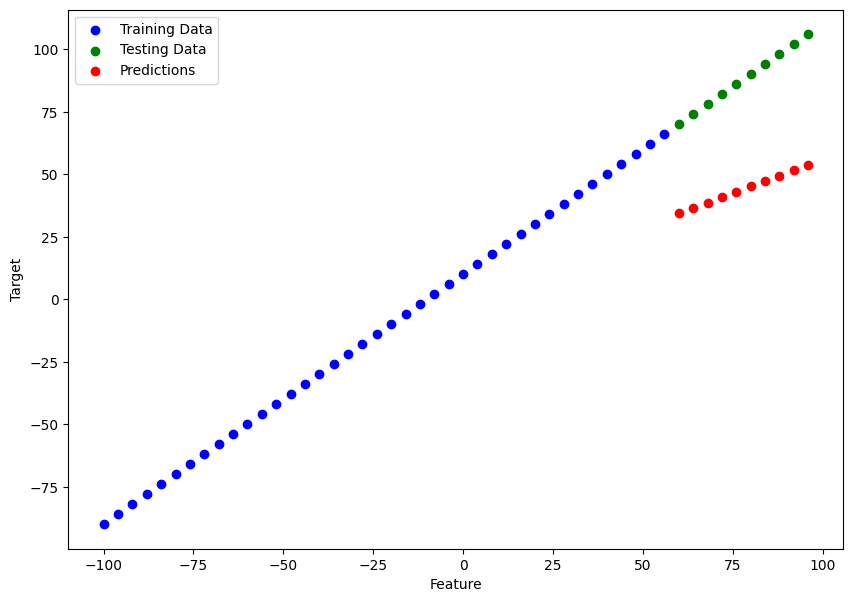

In [19]:
# Make and plot predictions for model_2
y_preds_2 = model_2.predict(x_test)
plot_predictions(predictions=y_preds_2)

In [20]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(np.float32(43.97525), np.float32(1961.782))

**Model_3:**

In [21]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_2
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model (this time for 500 epochs, not 100)
model_3.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=200)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - loss: 39.0999 - mae: 39.0999
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 30.2852 - mae: 30.2852
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 22.9179 - mae: 22.9179
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 19.5392 - mae: 19.5392
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 17.8142 - mae: 17.8142
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 17.1003 - mae: 17.1003
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.5407 - mae: 12.5407
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 15.0160 - mae: 15.0160
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.6522 - mae: 15.6522
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.3023 - mae: 12.3023
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.8683 - mae: 14.8683
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.4538 - mae: 11.4538
Epoch 13/200
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


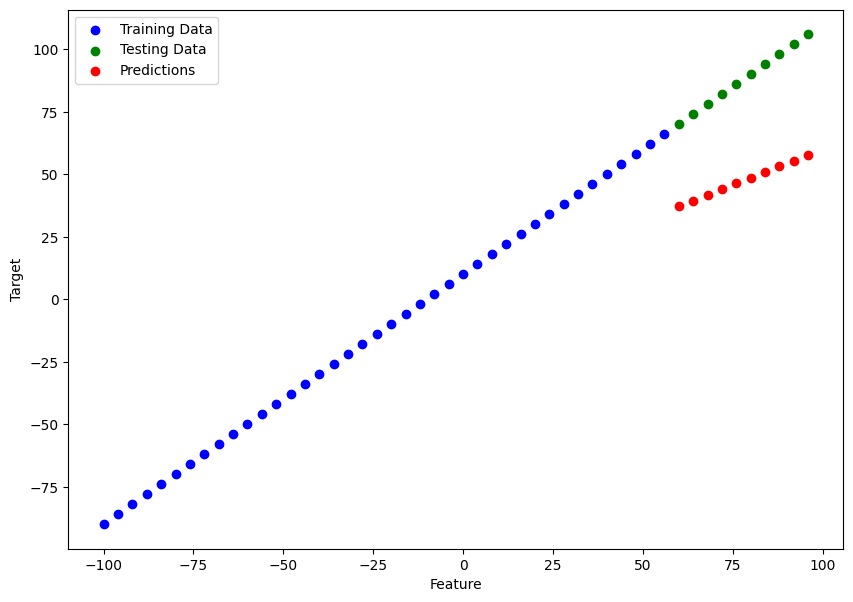

In [22]:
# Make and plot predictions for model_3
y_preds_3 = model_3.predict(x_test)
plot_predictions(predictions=y_preds_3)

In [23]:
# Calculate model_3 metrics
mae_3 = mae(y_test, y_preds_3.squeeze()).numpy()
mse_3 = mse(y_test, y_preds_3.squeeze()).numpy()
mae_3, mse_3

(np.float32(40.543938), np.float32(1668.0957))

## Comparing results

In [24]:
model_results = [["model_1", mae_1, mse_1],
                 ["model_2", mae_2, mse_2],
                 ["model_3", mae_3, mae_3]]

In [25]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,23.935459,577.992493
1,model_2,43.975250,1961.781982
2,model_3,40.543938,40.543938


Best Model is **Model_1**

## Saving Model

- There are two main formats:
    * The SavedModel format : <br>
        ```model_1.save("best_model_SavedModel_format")```
    * The HDF5 format : <br>
        ```model_1.save("best_model_HDF5_format.h5")```

## Load a saved model to use
```
loaded_model = tf.keras.models.load_model("MODEL_PATH")
```

---

# Practice On Real Dataset
**Medical Cost personal Datasets From Kaggle:** https://www.kaggle.com/datasets/mirichoi0218/insurance

In [26]:
# Import Libraries
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib as plt

In [27]:
# Read Data
data = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [28]:
# Feature Scaling and splitting

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Features and Labels
X = data.drop('charges', axis=1)
y = data['charges']

# column transformer: scale numeric columns, one-hot encode categorical columns
ct = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']),
    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region'])
)

# Splitting Data
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Fit the column transformer to out training data
ct.fit(x_train)

# Transform training and test data with normalization [ MinMaxScaler and OneHotEncoder ]
x_train_normal = ct.transform(x_train)
x_test_normal = ct.transform(x_test)

# inspect shapes
print(x_train_normal.shape, x_test_normal.shape)

(1070, 11) (268, 11)


In [29]:
# Building Neural Network

# Creating a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compiling a model
insurance_model.compile(loss = tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.SGD(),
                        metrics=["mae"])

# fitting a model
insurance_model.fit(x_train_normal, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s -29486us/step - loss: 13345.0674 - mae: 13345.0674
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13340.9414 - mae: 13340.9414
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13330.1416 - mae: 13330.1416
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13297.6240 - mae: 13297.6240
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13197.1084 - mae: 13197.1084
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12884.5293 - mae: 12884.5293
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11941.0078 - mae: 11941.0078
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10214.3828 - mae: 10214.3828
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8771.1934 - mae: 8771.1934
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8227.9844 - mae: 8227.9844
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7994.6963 - mae: 7994.6963
Epoch 12/100
34/34 ━━━━━━━━━━━━

In [30]:
# Evaluation
insurance_model.evaluate(x_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 3162.2576 - mae: 3162.2576


[3162.257568359375, 3162.257568359375]

In [31]:
# Experimenting models

# model_1

# creating model
insurance_model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compiling model
insurance_model_1.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# fit model
insurance_model_1.fit(x_train_normal, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 13344.3154 - mae: 13344.3154
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13337.5410 - mae: 13337.5410
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13319.2998 - mae: 13319.2998
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13279.5264 - mae: 13279.5264
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13207.1543 - mae: 13207.1543
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13091.3818 - mae: 13091.3818
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12921.7344 - mae: 12921.7344
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12687.9951 - mae: 12687.9951
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12380.1758 - mae: 12380.1758
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11990.9453 - mae: 11990.9453
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11527.5459 - mae: 11527.5459
Epoch 12/100
34/34 ━━━━━━━━

In [32]:
# Evaluate Model_1
insurance_model_1.evaluate(x_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - loss: 3434.9426 - mae: 3434.9426


[3434.942626953125, 3434.942626953125]

In [33]:
# Experimenting models

# model_2

# creating model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compiling model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# fit model
insurance_model_2.fit(x_train_normal, y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 13343.2920 - mae: 13343.2920
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13334.3311 - mae: 13334.3311
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13312.3379 - mae: 13312.3379
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13266.5811 - mae: 13266.5811
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13185.7070 - mae: 13185.7070
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13059.0420 - mae: 13059.0420
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12876.0098 - mae: 12876.0098
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12626.4971 - mae: 12626.4971
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12300.7891 - mae: 12300.7891
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11893.8936 - mae: 11893.8936
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11414.6787 - mae: 11414.6787
Epoch 12/200
34/34 

In [34]:
# Evaluate Model_2
insurance_model_2.evaluate(x_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 3160.7161 - mae: 3160.7161


[3160.716064453125, 3160.716064453125]

---